<a href="https://colab.research.google.com/github/WPHdamian/Data-Science-Curriculum-Analysis-/blob/main/06_alignment%2Banalysis_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Introduction

This notebook presents a quantitative analysis of the alignment between data science curricula and labour market skill demand. The study integrates curriculum data from universities in Hong Kong and London with job postings collected between November 2025 and February 2026.

Two taxonomies are used:
- **ESCO**: a machine-readable skill classification used for skill extraction
- **EDISON**: a competency framework for structuring data science capabilities

The analysis operates across three levels:

- **Macro-level**: overall distributional alignment between curricula and job market
- **Meso-level**: alignment across EDISON competency domains
- **Micro-level**: skill-level mismatches and gaps

Additionally, two comparative dimensions are introduced:
- **City-level**: Hong Kong vs London
- **Keyword-level**: programme types (e.g., Data Science, Business Analytics)

The objective is to systematically evaluate alignment and identify structural mismatches between education and labour demand.

# 1. Data Preparation

This section loads and prepares the datasets for analysis. The data consists of:

- Curriculum data (modules, descriptions, extracted skills)
- Job posting data (descriptions, extracted skills)

Both datasets contain:
- ESCO skill annotations
- EDISON domain mappings

The data is transformed into a long format to enable crosswalk construction.

In [4]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [5]:
import pandas as pd
import numpy as np
import ast
import re

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import jensenshannon
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

In [6]:
# Load datasets
jobs = pd.read_parquet("job_with_edison.parquet")
curr = pd.read_parquet("curriculum_with_edison.parquet")

In [7]:
list_cols = ['esco_skills', 'edison_domains']

def robust_list_converter(x):
    if isinstance(x, (list, np.ndarray)):
        return list(x)

    if pd.isnull(x):
        return []

    if isinstance(x, str):
        x = x.strip()

        if not x or x in ("[]", "None"):
            return []

        if "," in x and not x.startswith("["):
            return [i.strip() for i in x.split(",") if i.strip()]

        if x.startswith("array("):
            match = re.search(r'\[.*\]', x)
            if match:
                x = match.group(0)

        try:
            return ast.literal_eval(x)
        except:
            return [x]

    return [x]

for df in [jobs, curr]:
    for col in list_cols:
        if col in df.columns:
            df[col] = df[col].apply(robust_list_converter)

def flatten_esco(x):
    if not isinstance(x, list):
        return x
    out = []
    for i in x:
        if isinstance(i, str):
            parts = re.split(r"[;,]", i)
            out.extend([p.strip() for p in parts if p.strip()])
        else:
            out.append(i)
    return out

jobs['esco_skills'] = jobs['esco_skills'].apply(flatten_esco)
curr['esco_skills'] = curr['esco_skills'].apply(flatten_esco)

jobs_long = jobs.explode('esco_skills').explode('edison_domains')
curr_long = curr.explode('esco_skills').explode('edison_domains')

jobs_long['esco_skills'] = jobs_long['esco_skills'].astype(str).str.strip()
curr_long['esco_skills'] = curr_long['esco_skills'].astype(str).str.strip()

jobs_long = jobs_long[
    (jobs_long['esco_skills'].notna()) &
    (jobs_long['esco_skills'] != "") &
    (jobs_long['edison_domains'].notna())
]

curr_long = curr_long[
    (curr_long['esco_skills'].notna()) &
    (curr_long['esco_skills'] != "") &
    (curr_long['edison_domains'].notna())
]

jobs_exploded = jobs_long[['job_id', 'location', 'keyword', 'esco_skills', 'edison_domains']]
curr_exploded = curr_long[['module_id', 'city', 'keyword_list', 'esco_skills', 'edison_domains']]

jobs_exploded.head()

,job_id,location,keyword,esco_skills,edison_domains
1,4054500393,Hong Kong,Data Analytics,communicate technicalities with clients,DSDA
1,4054500393,Hong Kong,Data Analytics,communicate technicalities with clients,DSPC
1,4054500393,Hong Kong,Data Analytics,use presentation software,DSDA
1,4054500393,Hong Kong,Data Analytics,use presentation software,DSPC
1,4054500393,Hong Kong,Data Analytics,perform market research,DSDA


In [8]:
jobs_exploded.shape, curr_exploded.shape

((81326, 5), (21918, 5))

# 2. Data reduction

In [9]:
job_counts = jobs_exploded['esco_skills'].value_counts()
curr_counts = curr_exploded['esco_skills'].value_counts()

valid_skills = set(
    job_counts[job_counts > 5].index
).union(
    curr_counts[curr_counts > 3].index
)

jobs_clean = jobs_exploded[jobs_exploded['esco_skills'].isin(valid_skills)]
curr_clean = curr_exploded[curr_exploded['esco_skills'].isin(valid_skills)]

jobs_clean.shape, curr_clean.shape

((79622, 5), (21507, 5))

# 3. Crosswalk Construction

A crosswalk table is constructed linking:

- ESCO skills
- EDISON domains

For each combination, the following are computed:

- Job count (frequency in job postings)
- Curriculum count (frequency in curriculum)
- Normalised proportions
- Alignment metrics:
  - Gap (curriculum − job)
  - Alignment score (bounded ratio)

This crosswalk forms the foundation for all subsequent analyses.

In [10]:
# Job counts
job_counts = (
    jobs_clean
    .groupby(['location','esco_skills', 'edison_domains'])
    .size()
    .reset_index(name='job_count')
)

# Curriculum counts
curr_counts = (
    curr_clean
    .groupby(['city','esco_skills', 'edison_domains'])
    .size()
    .reset_index(name='curr_count')
)
curr_counts.columns=['location', 'esco_skills', 'edison_domains', 'curr_count']

# Merge
crosswalk = pd.merge(job_counts, curr_counts,
                     on=['location','esco_skills', 'edison_domains'],
                     how='outer').fillna(0)

# Normalisation
crosswalk['job_norm'] = crosswalk['job_count'] / crosswalk['job_count'].sum()
crosswalk['curr_norm'] = crosswalk['curr_count'] / crosswalk['curr_count'].sum()

# Gap
crosswalk['gap'] = crosswalk['curr_norm'] - crosswalk['job_norm']

# BOUNDED ALIGNMENT SCORE
crosswalk['alignment_score'] = (
    crosswalk['curr_norm'] /
    (crosswalk['curr_norm'] + crosswalk['job_norm'] + 1e-9)
)

# LOG ODDS RATIO
crosswalk['log_odds'] = np.log(
    (crosswalk['curr_count'] + 1) / (crosswalk['curr_count'].sum() - crosswalk['curr_count'] + 1)
) - np.log(
    (crosswalk['job_count'] + 1) / (crosswalk['job_count'].sum() - crosswalk['job_count'] + 1)
)

crosswalk.head()

,location,esco_skills,edison_domains,job_count,curr_count,job_norm,curr_norm,gap,alignment_score,log_odds
0,Hong Kong,3D modelling,DSENG,2.0,1.0,0.000025,0.000046,0.000021,0.649246,0.903434
1,Hong Kong,3D modelling,DSPC,2.0,0.0,0.000025,0.000000,-0.000025,0.000000,0.210241
2,Hong Kong,3D modelling,DSTF,0.0,1.0,0.000000,0.000046,0.000046,0.999978,2.002072
3,Hong Kong,APL,DSAD,1.0,0.0,0.000013,0.000000,-0.000013,0.000000,0.615718
4,Hong Kong,APL,DSBA,1.0,0.0,0.000013,0.000000,-0.000013,0.000000,0.615718


In [11]:
print("Total rows:", crosswalk.shape)
print("Curriculum-only skills:", (crosswalk['job_count']==0).sum())
print("Job-only skills:", (crosswalk['curr_count']==0).sum())

Total rows: (11128, 10)
Curriculum-only skills: 2799
Job-only skills: 5958


In [12]:
df=crosswalk.esco_skills.unique()
pd.Series(df).to_csv("filtered_esco_sets.csv", index=False)

# 4. Global Alignment Analysis

This section evaluates overall alignment between curriculum and job market distributions.

Three statistical measures are used:

1. **Jensen–Shannon Divergence (JSD)**
   - Measures similarity between distributions (bounded 0–1)

2. **Cosine Similarity**
   - Measures structural similarity of vectors

3. **Chi-Square Test**
   - Tests whether distributions differ significantly

4. **Cramér’s V**
   - Measures effect size of distribution differences

These metrics provide complementary perspectives on alignment.

In [13]:
# Aggregate at EDISON domain level
domain_job = crosswalk.groupby('edison_domains')['job_norm'].sum()
domain_curr = crosswalk.groupby('edison_domains')['curr_norm'].sum()

# Align indices
domain_job, domain_curr = domain_job.align(domain_curr, fill_value=0)

# Jensen-Shannon Divergence
jsd = jensenshannon(domain_job, domain_curr)

# Cosine similarity
cos_sim = cosine_similarity(
    domain_job.values.reshape(1, -1),
    domain_curr.values.reshape(1, -1)
)[0][0]

# Chi-square
contingency = crosswalk.pivot_table(
    index='edison_domains',
    values=['job_count', 'curr_count'],
    aggfunc='sum'
)
chi2, p, dof, expected = chi2_contingency(contingency)

# Cramér's V
n = contingency.values.sum()
r, k = contingency.shape
cramers_v = np.sqrt(chi2 / (n * (min(r-1, k-1))))

print("Overall metrics:")
print("Jensen-Shannon Divergence:", jsd)
print("Cosine similarity:", cos_sim)
print("Chi-square:", chi2)
print("p-value:", p)
print("Cramer's V:", cramers_v)

Overall metrics:
Jensen-Shannon Divergence: 0.1422371943264535
Cosine similarity: 0.9787539067242376
Chi-square: 2819.46871367468
p-value: 0.0
Cramer's V: 0.16697282056742574


# 5. Curriculum Structure: Hong Kong vs London

This section examines differences in curriculum structure between cities.

The analysis compares:
- Distribution of EDISON domains
- Structural emphasis in programme design

Statistical tests:
- Chi-square test (distribution difference)
- Cramér’s V (effect size)
- Jensen–Shannon Divergence (distribution similarity)

This directly addresses RQ1.

In [14]:
# 1. Build city-domain table (RAW COUNTS)
curr_city = (
    curr_clean
    .groupby(['city', 'edison_domains'])
    .size()
    .unstack(fill_value=0)
)

# 2. Ensure correct ordering + no missing columns
curr_city = curr_city.reindex(index=['Hong Kong', 'London']).fillna(0)

# 3. Normalize (row-wise)
curr_city_norm = curr_city.div(curr_city.sum(axis=1), axis=0)

# -------------------------
# CHI-SQUARE TEST
# -------------------------
chi2_city, p_city, _, _ = chi2_contingency(curr_city)

# -------------------------
# CRAMER'S V
# -------------------------
n = curr_city.values.sum()
r, k = curr_city.shape

cramers_v_city = np.sqrt(
    chi2_city / (n * (min(r - 1, k - 1)))
)

# -------------------------
# JENSEN–SHANNON DIVERGENCE
# -------------------------
hk = curr_city_norm.loc['Hong Kong']
ldn = curr_city_norm.loc['London']

jsd_city = jensenshannon(hk, ldn)

print("HK vs London (curriculum) metrics:")
print("Jensen-Shannon Divergence:", jsd_city)
print("Chi-square:", chi2_city)
print("p-value:", p_city)
print("Cramer's V:", cramers_v_city)

HK vs London (curriculum) metrics:
Jensen-Shannon Divergence: 0.08672300212160622
Chi-square: 286.16321138941345
p-value: 5.437917819802731e-58
Cramer's V: 0.11534983640195812


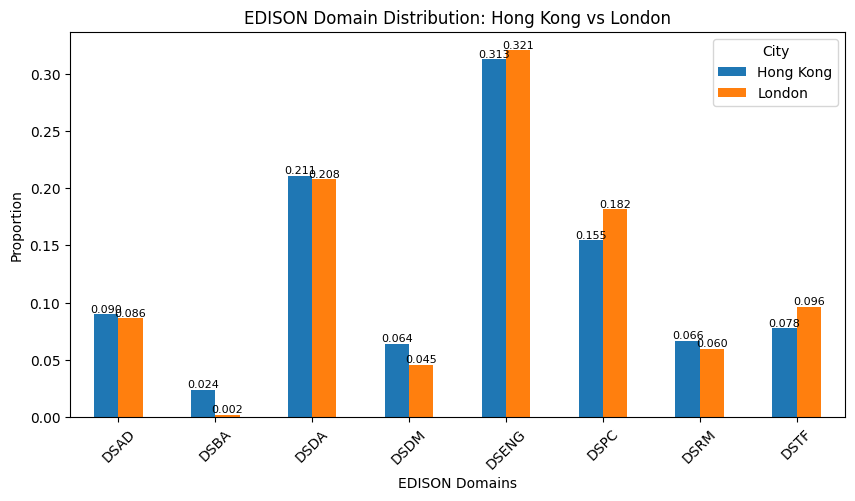

In [15]:
ax = curr_city_norm.T.plot(kind='bar', figsize=(10,5))

plt.title("EDISON Domain Distribution: Hong Kong vs London")
plt.ylabel("Proportion")
plt.xlabel("EDISON Domains")
plt.legend(title="City")
plt.xticks(rotation=45)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)

plt.show()

# 6. Keyword-Level Analysis (Programme Type Differences)

This section analyses how different programme types (keywords) structure their curricula and how these structures align with labour market demand.

Keywords include:
- Data Science
- Data Analytics
- Business Analytics
- Data Engineering
- Big Data

This analysis introduces a third analytical dimension:
- **Keyword × EDISON domain distribution**

Statistical tests:
- Chi-square test (distribution differences across programme types)
- Cramér’s V (effect size)
- Jensen–Shannon divergence (alignment with labour market)

This section addresses how pedagogical orientation varies across programme types.

In [16]:
# 1. Fix the SettingWithCopyWarning by explicitly making a copy
curr_clean = curr_clean.copy()
jobs_clean = jobs_clean.copy()

# 2. Use a more robust converter instead of ast.literal_eval
def robust_to_list(val):
    # 1. Handle cases where it's already a list or numpy array
    if isinstance(val, (list, np.ndarray)):
        return list(val)

    # 2. Handle nulls/NaNs safely for scalars
    if pd.isna(val):
        return []

    # 3. Handle strings and empty strings
    if isinstance(val, str):
        val = val.strip()
        if val == "" or val == "[]":
            return []
        # Check if it's a string representation of a list
        if val.startswith('[') and val.endswith(']'):
            try:
                return ast.literal_eval(val)
            except:
                return [val]
        return [val]

    # 4. Catch-all: wrap any other single values in a list
    return [val] if val is not None else []

# 3. Apply using .loc to be safe
curr_clean.loc[:, 'keyword_list'] = curr_clean['keyword_list'].apply(robust_to_list)
jobs_clean.loc[:, 'keyword'] = jobs_clean['keyword'].apply(robust_to_list)

# 4. Now explode will work perfectly
curr_kw = curr_clean.explode('keyword_list')
jobs_kw = jobs_clean.explode('keyword')

In [17]:
# Build keyword-domain matrix (curriculum side)
keyword_domain = (
    curr_kw
    .groupby(['keyword_list', 'edison_domains'])
    .size()
    .unstack(fill_value=0)
)

# Normalize per keyword
keyword_domain_norm = keyword_domain.div(keyword_domain.sum(axis=1), axis=0)

keyword_domain_norm.head()

edison_domains,DSAD,DSBA,DSDA,DSDM,DSENG,DSPC,DSRM,DSTF
keyword_list,,,,,,,,
Big Data,0.028571,0.051429,0.200000,0.085714,0.405714,0.160000,0.068571,0.000000
Business Analytics,0.082309,0.036868,0.252358,0.043155,0.252358,0.183481,0.111175,0.038297
Data Analytics,0.081417,0.032859,0.183644,0.071559,0.303760,0.130705,0.107338,0.088719
Data Engineering,0.073227,0.023646,0.149504,0.073989,0.398932,0.136537,0.070938,0.073227
Data Science,0.093002,0.001685,0.207763,0.054959,0.325823,0.175686,0.043799,0.097284


In [18]:
#JSD per keyword
job_domain = crosswalk.groupby('edison_domains')['job_norm'].sum()
job_domain = job_domain / job_domain.sum()

jsd_by_keyword = {}

for kw in keyword_domain_norm.index:
    vec = keyword_domain_norm.loc[kw]
    vec = vec / vec.sum()

    jsd_by_keyword[kw] = jensenshannon(vec, job_domain)

jsd_by_keyword

{'Big Data': np.float64(0.14406383457895505),
 'Business Analytics': np.float64(0.07122732912742522),
 'Data Analytics': np.float64(0.11989714584524094),
 'Data Engineering': np.float64(0.1375710454534067),
 'Data Science': np.float64(0.18927871845734198)}

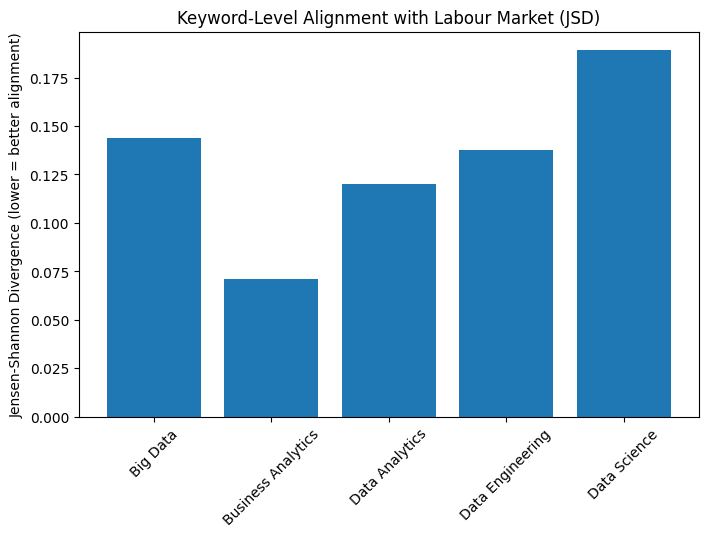

In [19]:
plt.figure(figsize=(8,5))
plt.bar(jsd_by_keyword.keys(), jsd_by_keyword.values())
plt.title("Keyword-Level Alignment with Labour Market (JSD)")
plt.ylabel("Jensen-Shannon Divergence (lower = better alignment)")
plt.xticks(rotation=45)
plt.show()

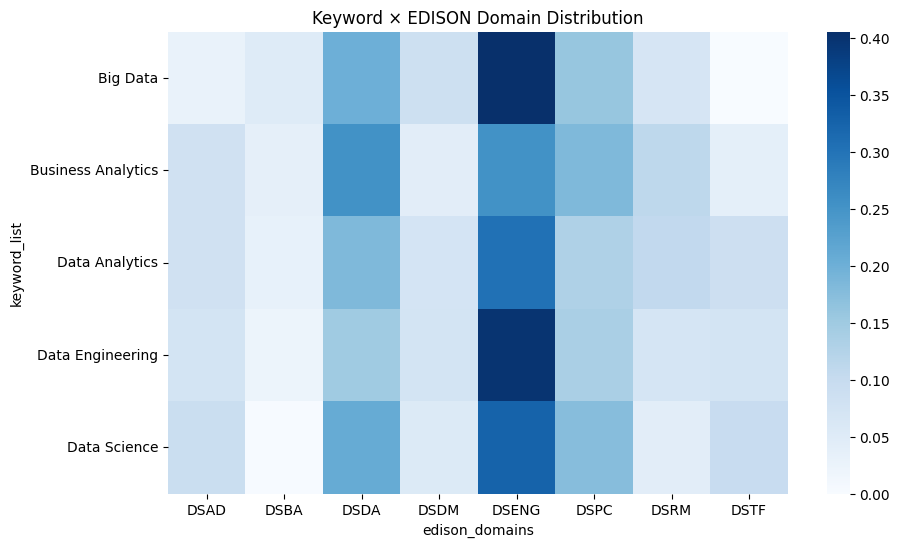

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(keyword_domain_norm, cmap="Blues")
plt.title("Keyword × EDISON Domain Distribution")
plt.show()

# 7. Skill-Level Analysis

This section evaluates alignment at the ESCO skill level, capturing fine-grained mismatches between curricula and labour market demand.

Two statistical approaches are used:

1. Proportion Z-test:
   - Tests whether a skill is significantly over/underrepresented

2. Log Odds Ratio:
   - Measures direction and magnitude of skill imbalance

This section provides the most granular evidence of misalignment.

In [21]:
skill_table = crosswalk.groupby(['location','esco_skills']).agg({
    'job_count': 'sum',
    'curr_count': 'sum'
}).reset_index()

skill_table.head()

,location,esco_skills,job_count,curr_count
0,Hong Kong,3D modelling,4.0,2.0
1,Hong Kong,APL,5.0,0.0
2,Hong Kong,ASP.NET,7.0,0.0
3,Hong Kong,Adobe Illustrator,4.0,0.0
4,Hong Kong,Adobe Photoshop,13.0,0.0


## 7.1 Proportion Z-test

In [22]:
def z_test(row):
    count = np.array([row['curr_count'], row['job_count']])
    nobs = np.array([
        curr_clean.shape[0],
        jobs_clean.shape[0]
    ])
    stat, p = proportions_ztest(count, nobs)
    return pd.Series([stat, p])

skill_table[['z_stat', 'p_value']] = skill_table.apply(z_test, axis=1)

skill_table.head()

,location,esco_skills,job_count,curr_count,z_stat,p_value
0,Hong Kong,3D modelling,4.0,2.0,0.722332,0.470090
1,Hong Kong,APL,5.0,0.0,-1.162169,0.245167
2,Hong Kong,ASP.NET,7.0,0.0,-1.375110,0.169097
3,Hong Kong,Adobe Illustrator,4.0,0.0,-1.039470,0.298586
4,Hong Kong,Adobe Photoshop,13.0,0.0,-1.874015,0.060928


## 7.2 Log Odds Ratio

In [23]:
skill_table['log_odds'] = np.log(
    (skill_table['curr_count'] + 1) /
    (curr_clean.shape[0] - skill_table['curr_count'] + 1)
) - np.log(
    (skill_table['job_count'] + 1) /
    (jobs_clean.shape[0] - skill_table['job_count'] + 1)
)

skill_table.head()

,location,esco_skills,job_count,curr_count,z_stat,p_value,log_odds
0,Hong Kong,3D modelling,4.0,2.0,0.722332,0.470090,0.798095
1,Hong Kong,APL,5.0,0.0,-1.162169,0.245167,-0.482944
2,Hong Kong,ASP.NET,7.0,0.0,-1.375110,0.169097,-0.770651
3,Hong Kong,Adobe Illustrator,4.0,0.0,-1.039470,0.298586,-0.300610
4,Hong Kong,Adobe Photoshop,13.0,0.0,-1.874015,0.060928,-1.330343


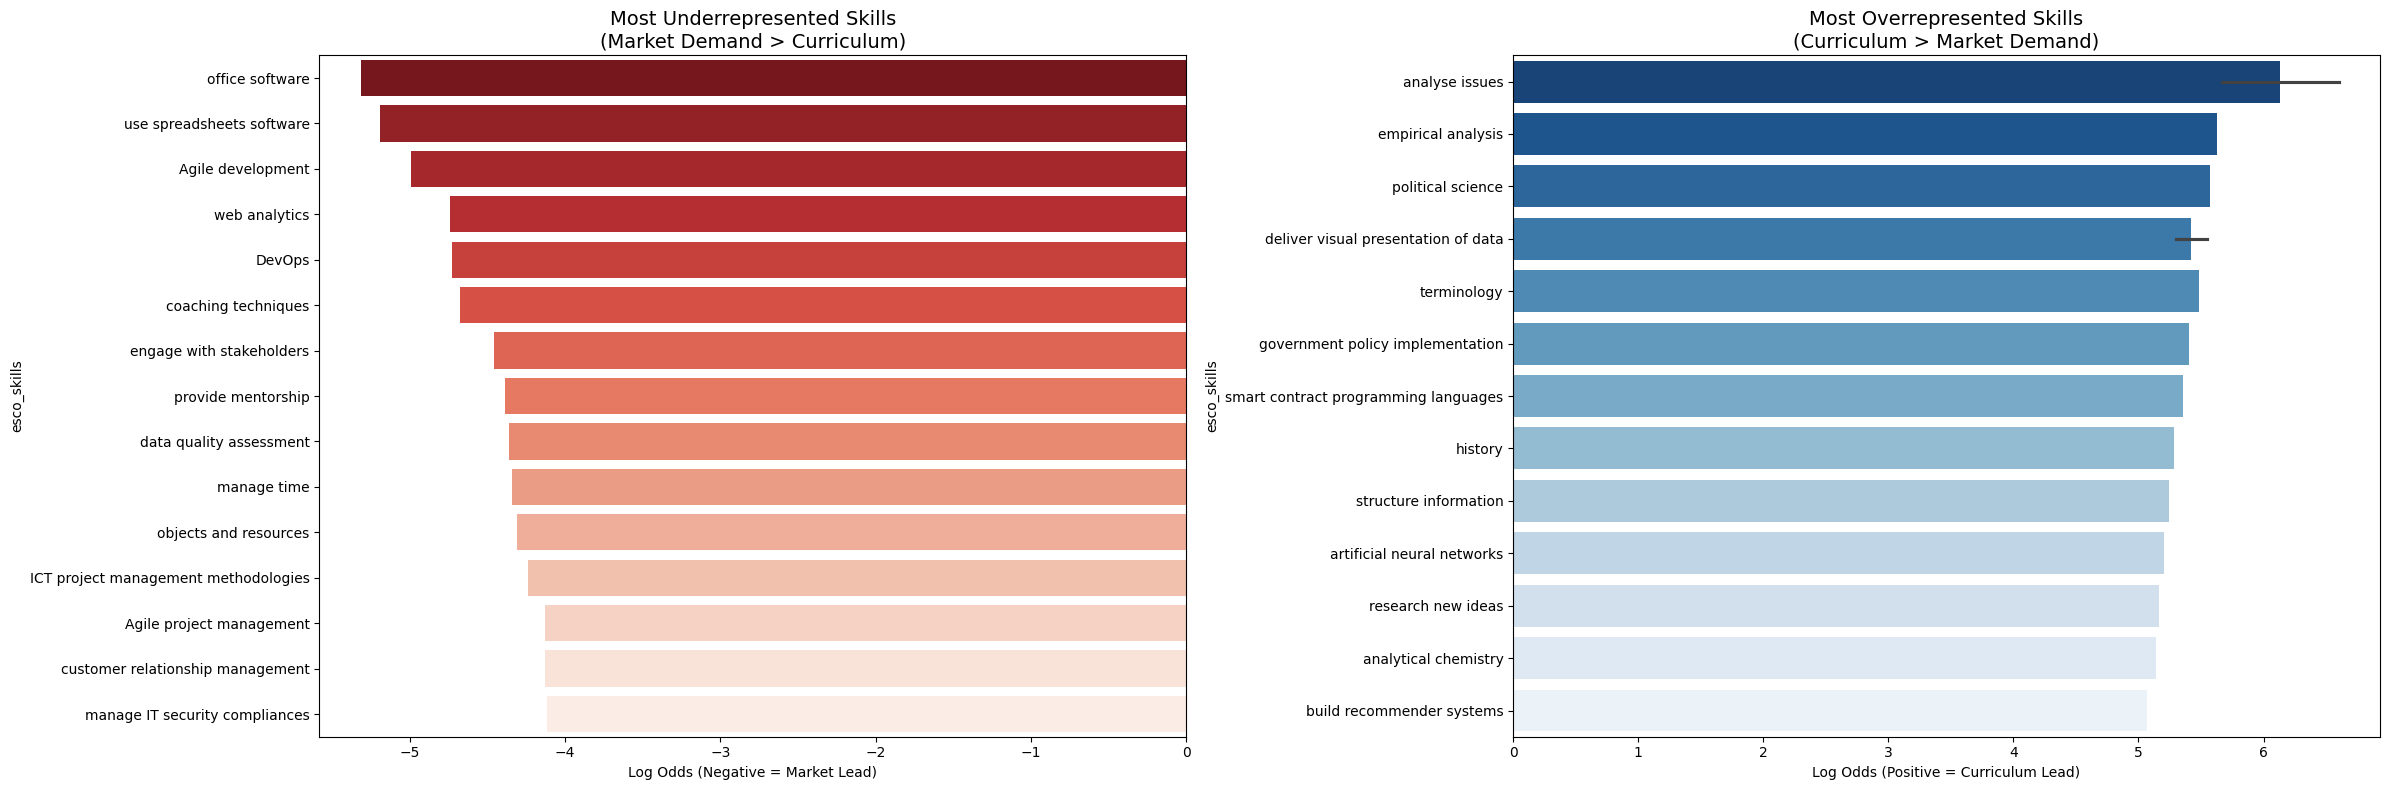

In [24]:
top_under = skill_table.sort_values('log_odds').head(15)
top_over = skill_table.sort_values('log_odds', ascending=False).head(15)

# Setup Subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# Plot Underrepresented (Left)
sns.barplot(data=top_under, x='log_odds', y='esco_skills', ax=axes[0], palette="Reds_r")
axes[0].set_title("Most Underrepresented Skills\n(Market Demand > Curriculum)", fontsize=14)
axes[0].set_xlabel("Log Odds (Negative = Market Lead)")

# Plot Overrepresented (Right)
sns.barplot(data=top_over, x='log_odds', y='esco_skills', ax=axes[1], palette="Blues_r")
axes[1].set_title("Most Overrepresented Skills\n(Curriculum > Market Demand)", fontsize=14)
axes[1].set_xlabel("Log Odds (Positive = Curriculum Lead)")

# Final Adjustments
plt.tight_layout()
plt.show()

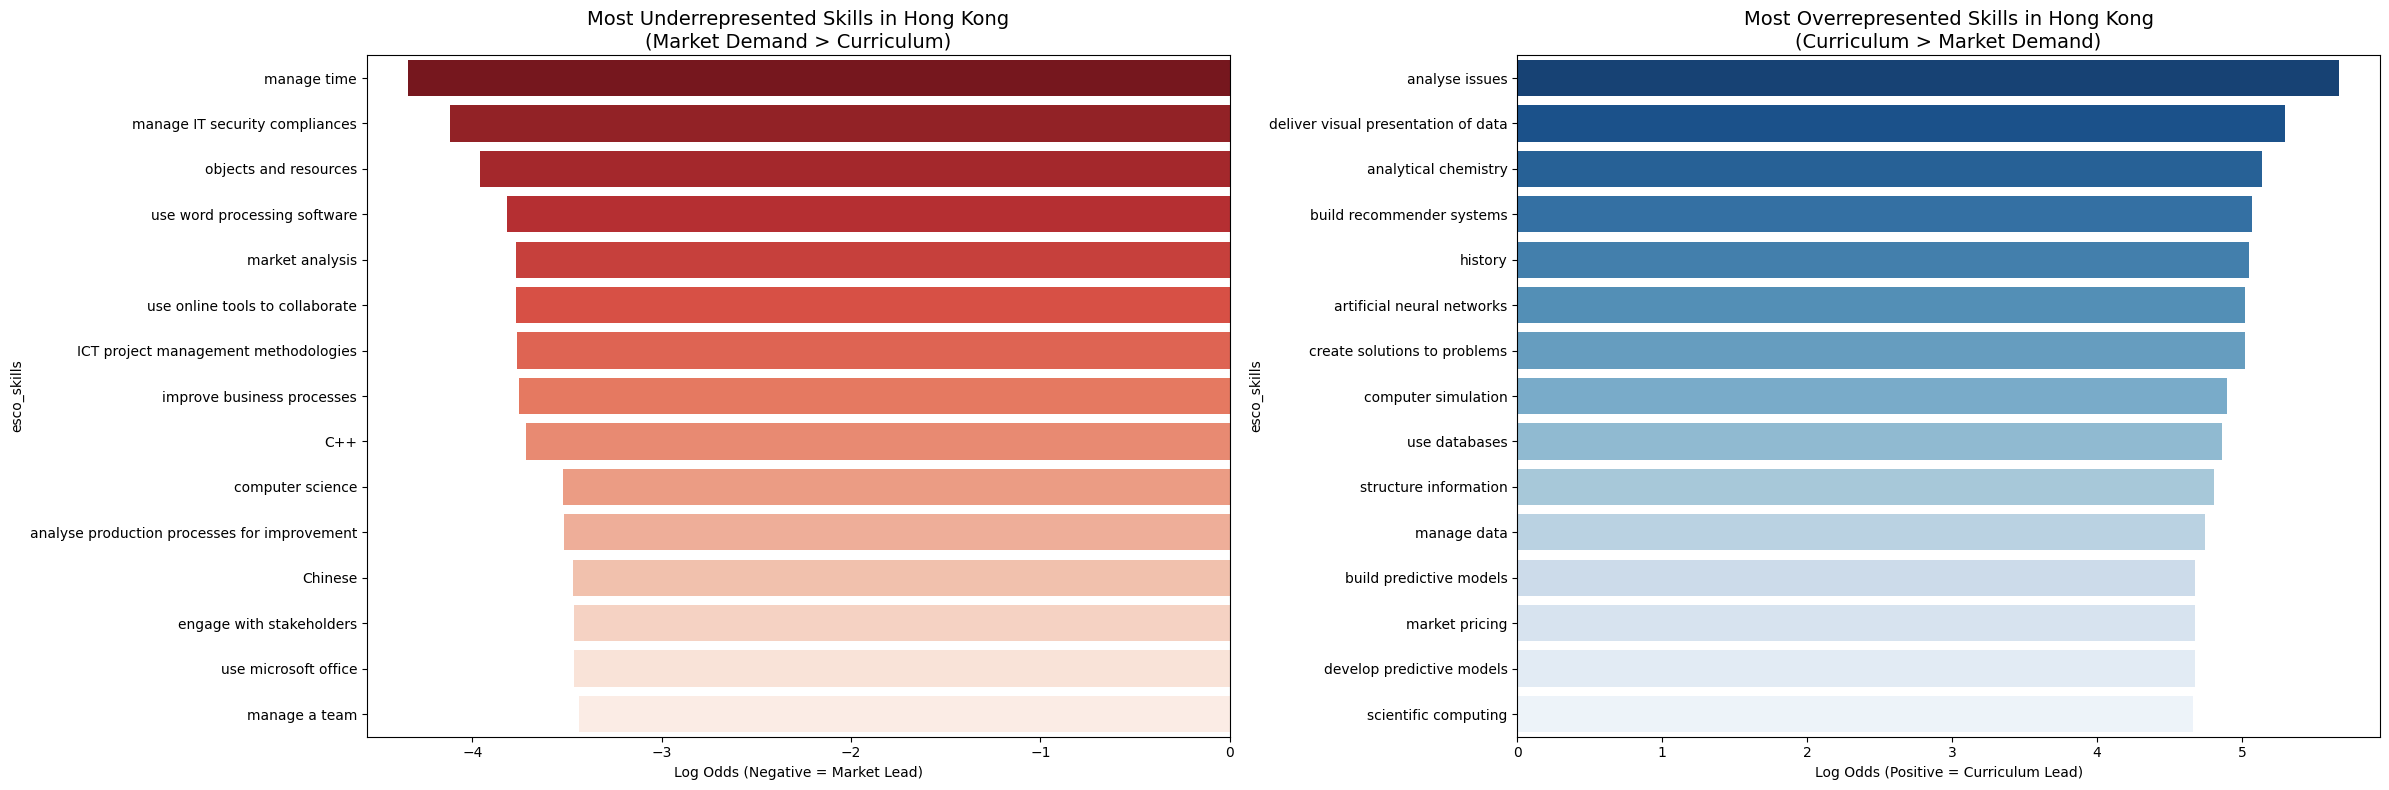

In [25]:
top_under_hk = skill_table[skill_table["location"]=="Hong Kong"].sort_values('log_odds').head(15)
top_over_hk = skill_table[skill_table["location"]=="Hong Kong"].sort_values('log_odds', ascending=False).head(15)

# Setup Subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# Plot Underrepresented (Left)
sns.barplot(data=top_under_hk, x='log_odds', y='esco_skills', ax=axes[0], palette="Reds_r")
axes[0].set_title("Most Underrepresented Skills in Hong Kong\n(Market Demand > Curriculum)", fontsize=14)
axes[0].set_xlabel("Log Odds (Negative = Market Lead)")

# Plot Overrepresented (Right)
sns.barplot(data=top_over_hk, x='log_odds', y='esco_skills', ax=axes[1], palette="Blues_r")
axes[1].set_title("Most Overrepresented Skills in Hong Kong\n(Curriculum > Market Demand)", fontsize=14)
axes[1].set_xlabel("Log Odds (Positive = Curriculum Lead)")

# Final Adjustments
plt.tight_layout()
plt.show()

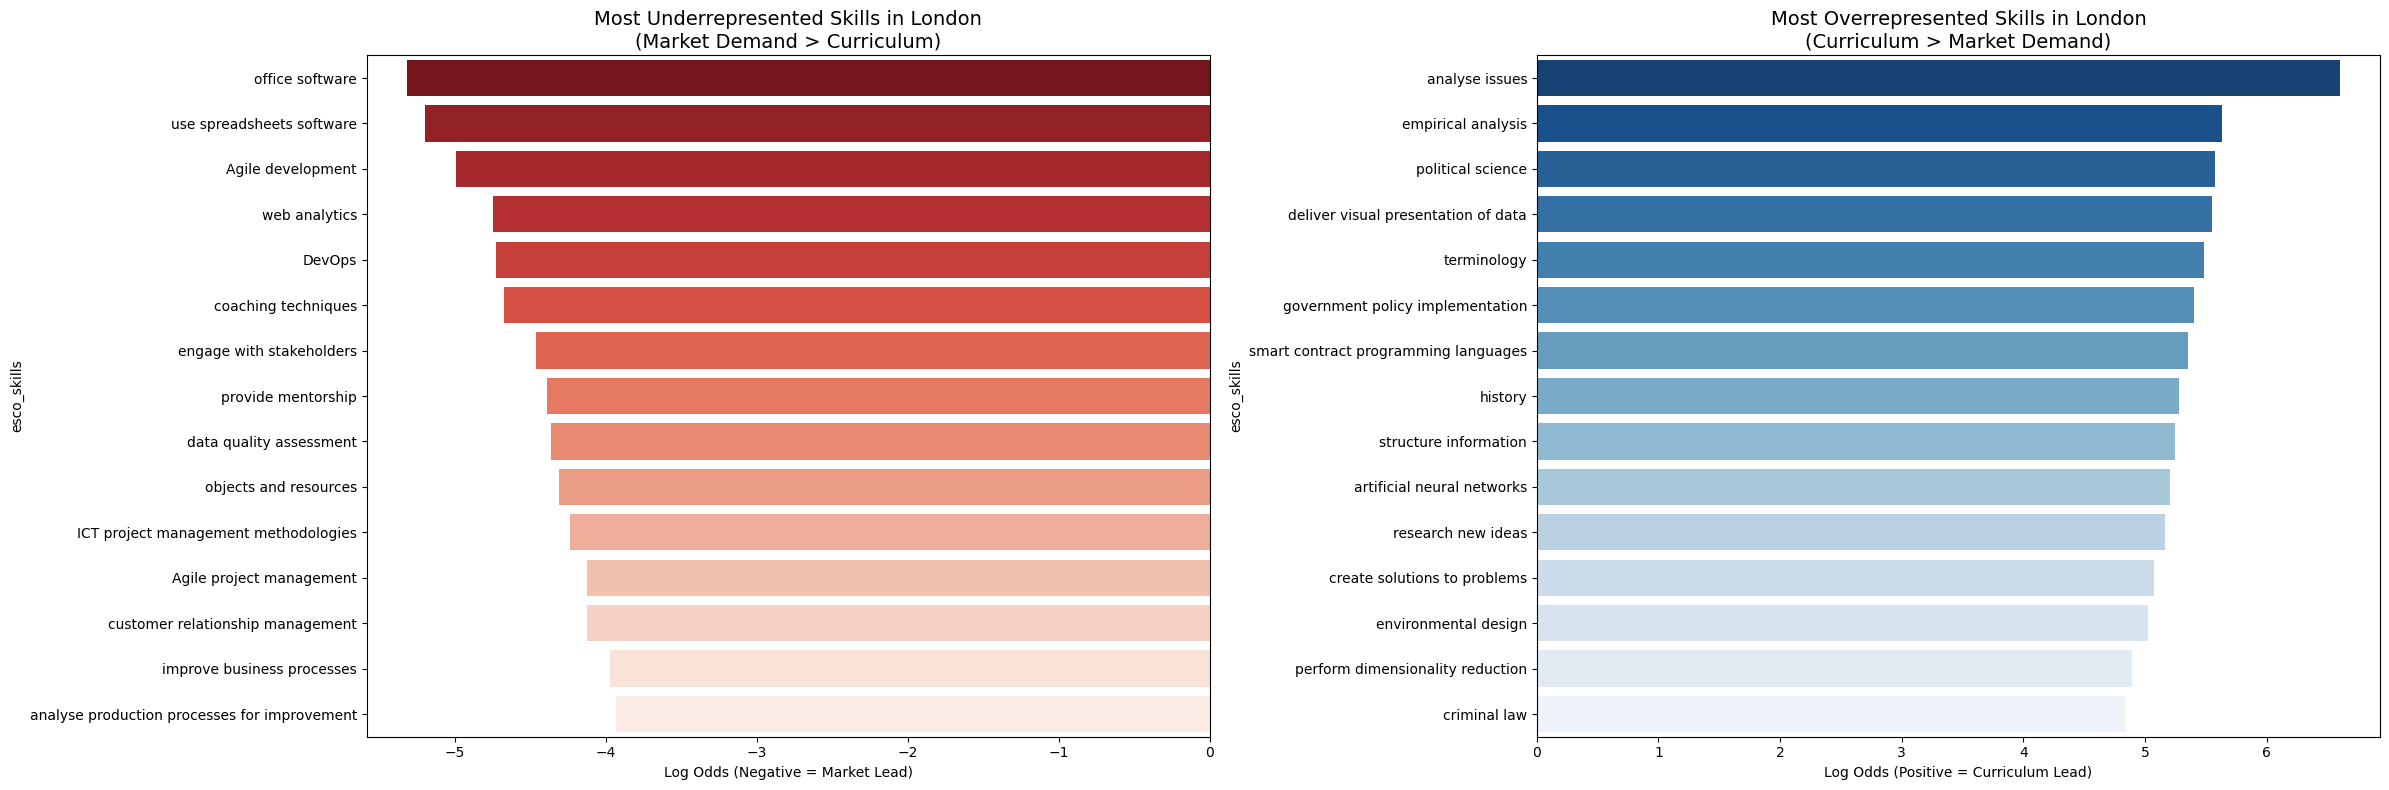

In [26]:
top_under_uk = skill_table[skill_table["location"]=="London"].sort_values('log_odds').head(15)
top_over_uk = skill_table[skill_table["location"]=="London"].sort_values('log_odds', ascending=False).head(15)

# Setup Subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# Plot Underrepresented (Left)
sns.barplot(data=top_under_uk, x='log_odds', y='esco_skills', ax=axes[0], palette="Reds_r")
axes[0].set_title("Most Underrepresented Skills in London\n(Market Demand > Curriculum)", fontsize=14)
axes[0].set_xlabel("Log Odds (Negative = Market Lead)")

# Plot Overrepresented (Right)
sns.barplot(data=top_over_uk, x='log_odds', y='esco_skills', ax=axes[1], palette="Blues_r")
axes[1].set_title("Most Overrepresented Skills in London\n(Curriculum > Market Demand)", fontsize=14)
axes[1].set_xlabel("Log Odds (Positive = Curriculum Lead)")

# Final Adjustments
plt.tight_layout()
plt.show()

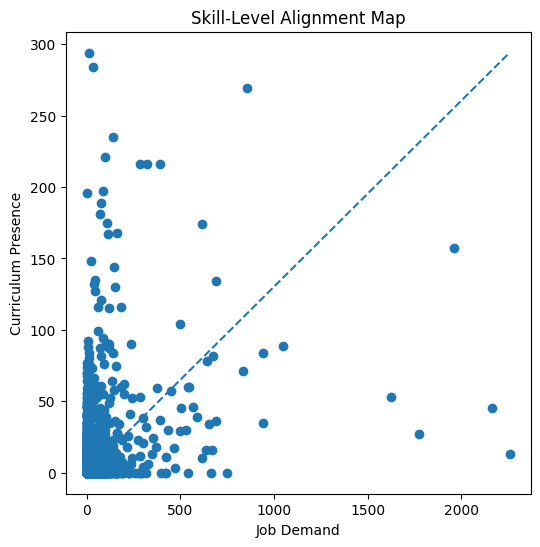

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(skill_table['job_count'], skill_table['curr_count'])
plt.xlabel("Job Demand")
plt.ylabel("Curriculum Presence")
plt.title("Skill-Level Alignment Map")

plt.plot([0, max(skill_table['job_count'])],
         [0, max(skill_table['curr_count'])],
         linestyle="--")

plt.show()

# 8. Skill Hierarchy (EDISON → ESCO Mapping)

This section visualises hierarchical relationships between EDISON domains and ESCO skills.

A Top-N filtering approach is used to ensure interpretability.

The goal is to:
- identify dominant skills within each domain
- visualise structural emphasis in curricula and labour market

In [28]:
remove_skills = [
    "solve problems",
    "comply with regulations",
    "lead others",
    "advise others",
    "English",
    "Chinese",
    "advise others",
    "perform project management",
    "project management principles",
    "ensure regulatory compliance concerning distribution activities",
    "advise on risk management"
]

filtered = crosswalk[
    ~(
        (crosswalk['esco_skills'].isin(remove_skills)) &
        (crosswalk['edison_domains'] != 'DSPC')
    )
]

topN = (
    filtered
    .sort_values('job_count', ascending=False)
    .groupby('edison_domains')
    .head(8)
)

In [29]:
import plotly.express as px

fig = px.treemap(
    topN,
    path=['edison_domains', 'esco_skills'],
    values='job_count',
    color='alignment_score',
    color_continuous_scale='RdBu',
    title="EDISON → ESCO Skill Hierarchy (Top-N)"
)

fig.show()

# 9. Crosswalk Heatmap

This section provides a structural overview of the ESCO × EDISON relationship.

Due to high dimensionality, a filtered Top-N dataset is used.

The heatmap highlights:
- concentration of skill demand
- domain-specific skill clusters
- curriculum–labour mismatch patterns

In [30]:
heatmap_data = crosswalk.pivot_table(
    index='esco_skills',
    columns='edison_domains',
    values='job_count',
    fill_value=0
)

# reduce noise (top 30 skills)
top_skills = (
    crosswalk.groupby('esco_skills')['job_count']
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .index
)

heatmap_filtered = heatmap_data.loc[top_skills]

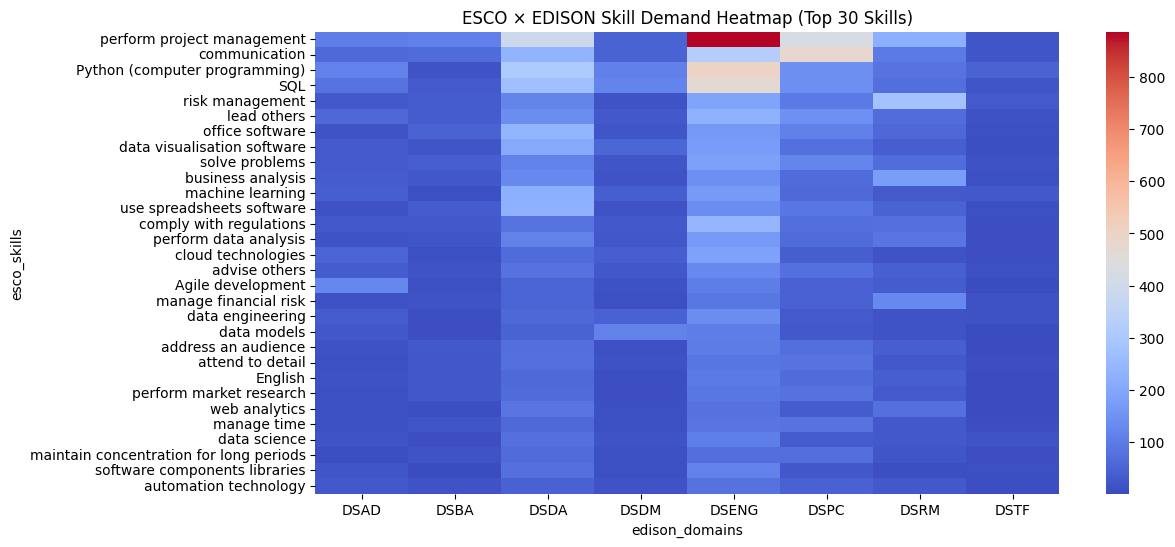

In [31]:
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_filtered, cmap="coolwarm")
plt.title("ESCO × EDISON Skill Demand Heatmap (Top 30 Skills)")
plt.show()

# 10. Preparation for Synthesis

This section prepares outputs for final interpretation.

Outputs integrated in later sections:
- Global alignment metrics (JSD, cosine similarity)
- Keyword-level differences
- Skill-level gaps (log odds)
- Structural hierarchy (treemap)

These results will be synthesised into:
- curriculum design implications
- labour market mismatch analysis
- policy interpretation (RQ3)

# Export datasets for dashboard

In [32]:
metrics = pd.DataFrame({
    "jsd": [jsd],
    "cosine_similarity": [cos_sim],
    "cramers_v": [cramers_v],
    "total_skills": [crosswalk['esco_skills'].nunique()]
})
metrics

,jsd,cosine_similarity,cramers_v,total_skills
0,0.142237,0.978754,0.166973,1240


In [33]:
domain_alignment = crosswalk.groupby('edison_domains').agg({
    'job_norm': 'sum',
    'curr_norm': 'sum'
}).reset_index()

domain_alignment['gap'] = domain_alignment['curr_norm'] - domain_alignment['job_norm']
domain_alignment

,edison_domains,job_norm,curr_norm,gap
0,DSAD,0.066640,0.088157,0.021517
1,DSBA,0.057045,0.012787,-0.044258
2,DSDA,0.206513,0.209281,0.002767
3,DSDM,0.048655,0.054819,0.006164
4,DSENG,0.313042,0.316827,0.003785
5,DSPC,0.175429,0.168178,-0.007251
6,DSRM,0.107156,0.063003,-0.044154
7,DSTF,0.025521,0.086948,0.061428


In [34]:
city_domain = curr_clean.groupby(['city', 'edison_domains']).size().reset_index(name='count')

city_domain['norm'] = city_domain.groupby('city')['count'].transform(lambda x: x / x.sum())
city_domain.head()

,city,edison_domains,count,norm
0,Hong Kong,DSAD,967,0.089878
1,Hong Kong,DSBA,255,0.023701
2,Hong Kong,DSDA,2268,0.210800
3,Hong Kong,DSDM,690,0.064132
4,Hong Kong,DSENG,3366,0.312854


In [35]:
keyword_domain = (
    curr_kw
    .groupby(['keyword_list', 'edison_domains'])
    .size()
    .reset_index(name='count')
)

keyword_domain['norm'] = keyword_domain.groupby('keyword_list')['count'].transform(lambda x: x / x.sum())
keyword_domain.head()

,keyword_list,edison_domains,count,norm
0,Big Data,DSAD,5,0.028571
1,Big Data,DSBA,9,0.051429
2,Big Data,DSDA,35,0.200000
3,Big Data,DSDM,15,0.085714
4,Big Data,DSENG,71,0.405714


In [36]:
jsd_df = pd.DataFrame(list(jsd_by_keyword.items()), columns=['keyword', 'jsd'])
jsd_df

,keyword,jsd
0,Big Data,0.144064
1,Business Analytics,0.071227
2,Data Analytics,0.119897
3,Data Engineering,0.137571
4,Data Science,0.189279


In [37]:
skill_table_export = skill_table[[
    'esco_skills',
    'job_count',
    'curr_count',
    'log_odds'
]].copy()

skill_table_export = skill_table_export[
    (skill_table_export['job_count'] > 5) |
    (skill_table_export['curr_count'] > 5)
]

skill_table_export.head()

,esco_skills,job_count,curr_count,log_odds
2,ASP.NET,7.0,0.0,-0.770651
4,Adobe Photoshop,13.0,0.0,-1.330343
5,Agile development,238.0,6.0,-2.224390
6,Agile project management,80.0,6.0,-1.140387
7,Android (mobile operating systems),8.0,6.0,1.057742


In [38]:
top_skills = (
    crosswalk.groupby('esco_skills')['job_count']
    .sum()
    .sort_values(ascending=False)
    .head(100)
    .index
)

crosswalk_top = crosswalk[crosswalk['esco_skills'].isin(top_skills)]
crosswalk_top.head()

,location,esco_skills,edison_domains,job_count,curr_count,job_norm,curr_norm,gap,alignment_score,log_odds
19,Hong Kong,Agile development,DSAD,80.0,2.0,0.001005,0.000093,-0.000912,0.084713,-1.987871
20,Hong Kong,Agile development,DSBA,6.0,0.0,0.000075,0.000000,-0.000075,0.000000,-0.637107
21,Hong Kong,Agile development,DSDA,23.0,0.0,0.000289,0.000000,-0.000289,0.000000,-1.869465
22,Hong Kong,Agile development,DSDM,5.0,0.0,0.000063,0.000000,-0.000063,0.000000,-0.482944
23,Hong Kong,Agile development,DSENG,65.0,2.0,0.000816,0.000093,-0.000723,0.102263,-1.782888


In [39]:
import os
os.makedirs("dashboard_data", exist_ok=True)

metrics.to_json("dashboard_data/metrics.json")
domain_alignment.to_json("dashboard_data/domain_alignment.json")
city_domain.to_json("dashboard_data/city_domain.json")
keyword_domain.to_json("dashboard_data/keyword_domain.json")
jsd_df.to_json("dashboard_data/jsd_keyword.json")
skill_table_export.to_json("dashboard_data/skill_table.json")
crosswalk_top.to_json("dashboard_data/crosswalk.json")